In [3]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers

# Reproducibilidad
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

# Permitir que TensorFlow use la memoria GPU progresivamente
gpus = tf.config.list_physical_devices("GPU")

for gpu in gpus:
    try:
        tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError as error:
        print("No se pudo configurar memory growth:", error)

# Configuración general
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# Entrenamiento
EPOCHS_FASE1 = 25
EPOCHS_FASE2 = 15

# Directorios
BASE_DIR = "../dataset"

TRAIN_DIR = os.path.join(BASE_DIR, "train")
VALID_DIR = os.path.join(BASE_DIR, "validation")
TEST_DIR = os.path.join(BASE_DIR, "test")

# Clases
CLASSES = [
    "cardboard",
    "glass",
    "metal",
    "paper",
    "plastic",
    "trash"
]

N_CLASSES = len(CLASSES)

print("TensorFlow:", tf.__version__)
print("GPU detectada:", gpus)
print("Train:", os.listdir(TRAIN_DIR))
print("Valid:", os.listdir(VALID_DIR))
print("Test:", os.listdir(TEST_DIR))

TensorFlow: 2.21.0
GPU detectada: []
Train: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']
Valid: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']
Test: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']


In [4]:
# Conteo de imágenes por clase

def contar_imagenes_por_clase(ruta):
    extensiones_validas = (".jpg", ".jpeg", ".png", ".webp")

    conteo = {}

    for clase in CLASSES:
        carpeta = os.path.join(ruta, clase)

        if not os.path.isdir(carpeta):
            raise FileNotFoundError(
                f"No se encontró la carpeta de la clase '{clase}': {carpeta}"
            )

        conteo[clase] = sum(
            1
            for archivo in os.listdir(carpeta)
            if (
                os.path.isfile(os.path.join(carpeta, archivo))
                and archivo.lower().endswith(extensiones_validas)
            )
        )

    return conteo


train_count = contar_imagenes_por_clase(TRAIN_DIR)
valid_count = contar_imagenes_por_clase(VALID_DIR)
test_count = contar_imagenes_por_clase(TEST_DIR)

print("Train:", train_count)
print("Valid:", valid_count)
print("Test:", test_count)

print("\nTotales:")
print("Train:", sum(train_count.values()))
print("Valid:", sum(valid_count.values()))
print("Test:", sum(test_count.values()))

Train: {'cardboard': 282, 'glass': 350, 'metal': 287, 'paper': 415, 'plastic': 337, 'trash': 95}
Valid: {'cardboard': 60, 'glass': 75, 'metal': 61, 'paper': 89, 'plastic': 72, 'trash': 20}
Test: {'cardboard': 61, 'glass': 76, 'metal': 62, 'paper': 90, 'plastic': 73, 'trash': 22}

Totales:
Train: 1766
Valid: 377
Test: 384


In [5]:
# Cálculo de class_weights

from sklearn.utils.class_weight import compute_class_weight

# Relación entre el nombre de cada clase y su índice
class_indices = {
    clase: indice
    for indice, clase in enumerate(CLASSES)
}

# Construir una lista con la clase de cada imagen de entrenamiento
y_train = []

for clase in CLASSES:
    indice_clase = class_indices[clase]
    cantidad_imagenes = train_count[clase]

    y_train.extend([indice_clase] * cantidad_imagenes)

y_train = np.array(y_train)

# Calcular pesos balanceados
class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=np.arange(N_CLASSES),
    y=y_train
)

# Convertir a diccionario compatible con Keras
class_weights = {
    indice: float(peso)
    for indice, peso in enumerate(class_weights_array)
}

print("Class weights:")

for indice, peso in class_weights.items():
    print(f"{indice} - {CLASSES[indice]:10s}: {peso:.4f}")

Class weights:
0 - cardboard : 1.0437
1 - glass     : 0.8410
2 - metal     : 1.0256
3 - paper     : 0.7092
4 - plastic   : 0.8734
5 - trash     : 3.0982


In [6]:
# Creación de entrenamiento

train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    labels="inferred",
    label_mode="categorical",
    class_names=CLASSES,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED
)

valid_ds = tf.keras.utils.image_dataset_from_directory(
    VALID_DIR,
    labels="inferred",
    label_mode="categorical",
    class_names=CLASSES,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    labels="inferred",
    label_mode="categorical",
    class_names=CLASSES,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

# Guardar antes de aplicar prefetch
class_names = train_ds.class_names

AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(AUTOTUNE)
valid_ds = valid_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)

print("Clases:", class_names)

Found 1766 files belonging to 6 classes.
Found 377 files belonging to 6 classes.
Found 384 files belonging to 6 classes.
Clases: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']


In [7]:
# Data augmentation

data_augmentation = keras.Sequential(
    [
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.10),
        layers.RandomZoom(0.10),
        layers.RandomContrast(0.10),
        layers.RandomTranslation(
            height_factor=0.05,
            width_factor=0.05
        ),
    ],
    name="data_augmentation"
)

In [8]:
# Función para construir el modelo

def crear_modelo_optuna(trial):
    # Hiperparámetros que Optuna probará
    dense_units = trial.suggest_categorical(
        "dense_units",
        [64, 128, 256]
    )

    dropout_rate = trial.suggest_float(
        "dropout_rate",
        0.20,
        0.50,
        step=0.05
    )

    learning_rate = trial.suggest_float(
        "learning_rate",
        1e-5,
        1e-3,
        log=True
    )

    optimizer_name = trial.suggest_categorical(
        "optimizer",
        ["adam", "rmsprop"]
    )

    # Modelo base nuevo para cada trial
    base_model_trial = keras.applications.MobileNetV3Small(
        input_shape=IMG_SIZE + (3,),
        include_top=False,
        weights="imagenet",
        include_preprocessing=True
    )

    # En la búsqueda inicial dejamos el backbone congelado
    base_model_trial.trainable = False

    inputs = keras.Input(
        shape=IMG_SIZE + (3,)
    )

    x = data_augmentation(inputs)
    x = base_model_trial(
        x,
        training=False
    )

    x = layers.GlobalAveragePooling2D()(x)

    x = layers.Dense(
        dense_units,
        activation="relu"
    )(x)

    x = layers.Dropout(
        dropout_rate
    )(x)

    outputs = layers.Dense(
        N_CLASSES,
        activation="softmax"
    )(x)

    model = keras.Model(
        inputs=inputs,
        outputs=outputs
    )

    if optimizer_name == "adam":
        optimizer = keras.optimizers.Adam(
            learning_rate=learning_rate
        )
    else:
        optimizer = keras.optimizers.RMSprop(
            learning_rate=learning_rate
        )

    model.compile(
        optimizer=optimizer,
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [9]:
# Crear función objective(trial)

def objective(trial):
    # Limpiar modelos anteriores para evitar acumulación de memoria
    keras.backend.clear_session()

    # Crear un modelo con los hiperparámetros sugeridos
    model = crear_modelo_optuna(trial)

    callbacks_trial = [
        keras.callbacks.EarlyStopping(
            monitor="val_accuracy",
            patience=3,
            mode="max",
            restore_best_weights=True,
            verbose=0
        ),

        keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=2,
            min_lr=1e-7,
            verbose=0
        )
    ]

    history = model.fit(
        train_ds,
        validation_data=valid_ds,
        epochs=8,
        class_weight=class_weights,
        callbacks=callbacks_trial,
        verbose=0
    )

    # Mejor accuracy de validación alcanzada por el trial
    best_val_accuracy = max(
        history.history["val_accuracy"]
    )

    print(
        f"Trial {trial.number} | "
        f"Mejor val_accuracy: {best_val_accuracy:.4f}"
    )

    return best_val_accuracy

In [10]:
# Crear estudio para maximizar la accuracy de validación

import optuna

study = optuna.create_study(
    direction="maximize",
    study_name="TrashNet_MobileNetV3_Optuna"
)

# Ejecutar búsqueda
study.optimize(
    objective,
    n_trials=10
)

[I 2026-07-21 11:02:55,675] A new study created in memory with name: TrashNet_MobileNetV3_Optuna


c:\Users\tomas\AppData\Local\Python\pythoncore-3.12-64\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(
[I 2026-07-21 11:04:07,097] Trial 0 finished with value: 0.7984085083007812 and parameters: {'dense_units': 128, 'dropout_rate': 0.45, 'learning_rate': 0.0002762019869627646, 'optimizer': 'rmsprop'}. Best is trial 0 with value: 0.7984085083007812.


Trial 0 | Mejor val_accuracy: 0.7984


[I 2026-07-21 11:05:13,736] Trial 1 finished with value: 0.40848806500434875 and parameters: {'dense_units': 128, 'dropout_rate': 0.45, 'learning_rate': 1.207175653443291e-05, 'optimizer': 'adam'}. Best is trial 0 with value: 0.7984085083007812.


Trial 1 | Mejor val_accuracy: 0.4085


...

Trial 7 | Mejor val_accuracy: 0.6578


[I 2026-07-21 11:13:24,552] Trial 8 finished with value: 0.45092839002609253 and parameters: {'dense_units': 128, 'dropout_rate': 0.35000000000000003, 'learning_rate': 1.3332850016627955e-05, 'optimizer': 'rmsprop'}. Best is trial 3 with value: 0.8408488035202026.


Trial 8 | Mejor val_accuracy: 0.4509


[I 2026-07-21 11:14:27,327] Trial 9 finished with value: 0.6366047859191895 and parameters: {'dense_units': 64, 'dropout_rate': 0.35000000000000003, 'learning_rate': 4.3396891525417586e-05, 'optimizer': 'rmsprop'}. Best is trial 3 with value: 0.8408488035202026.


Trial 9 | Mejor val_accuracy: 0.6366


In [11]:
# Resultados optuna

print("Mejor trial:", study.best_trial.number)
print("Mejor val_accuracy:", study.best_value)

print("\nMejores hiperparámetros:")

for parametro, valor in study.best_params.items():
    print(f"{parametro}: {valor}")

Mejor trial: 3
Mejor val_accuracy: 0.8408488035202026

Mejores hiperparámetros:
dense_units: 256
dropout_rate: 0.30000000000000004
learning_rate: 0.0002454336394236002
optimizer: rmsprop


In [12]:
# Recuperar parámetros

best_params = study.best_params

BEST_DENSE_UNITS = best_params["dense_units"]
BEST_DROPOUT = best_params["dropout_rate"]
BEST_LR = best_params["learning_rate"]
BEST_OPTIMIZER = best_params["optimizer"]

print("Parámetros seleccionados:")
print("Dense units:", BEST_DENSE_UNITS)
print("Dropout:", BEST_DROPOUT)
print("Learning rate:", BEST_LR)
print("Optimizer:", BEST_OPTIMIZER)

Parámetros seleccionados:
Dense units: 256
Dropout: 0.30000000000000004
Learning rate: 0.0002454336394236002
Optimizer: rmsprop


In [13]:
# Creación del modelo final

keras.backend.clear_session()

base_model = keras.applications.MobileNetV3Small(
    input_shape=IMG_SIZE + (3,),
    include_top=False,
    weights="imagenet",
    include_preprocessing=True
)

base_model.trainable = False

inputs = keras.Input(shape=IMG_SIZE + (3,))

x = data_augmentation(inputs)

x = base_model(
    x,
    training=False
)

x = layers.GlobalAveragePooling2D()(x)

x = layers.Dense(
    BEST_DENSE_UNITS,
    activation="relu"
)(x)

x = layers.Dropout(
    BEST_DROPOUT
)(x)

outputs = layers.Dense(
    N_CLASSES,
    activation="softmax"
)(x)

model_optuna = keras.Model(
    inputs=inputs,
    outputs=outputs
)

if BEST_OPTIMIZER == "adam":
    optimizer_final = keras.optimizers.Adam(
        learning_rate=BEST_LR
    )
else:
    optimizer_final = keras.optimizers.RMSprop(
        learning_rate=BEST_LR
    )

model_optuna.compile(
    optimizer=optimizer_final,
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model_optuna.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MobileNetV3Small (Functional)   │ (None, 7, 7, 576)      │       939,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 576)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       147,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,088,374 (4.15 MB)

 Trainable params: 149,254 (583.02 KB)

 Non-trainable params: 939,120 (3.58 MB)

In [14]:
# Callbacks para el entrenamiento final

callbacks_fase1 = [
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=5,
        mode="max",
        restore_best_weights=True,
        verbose=1
    ),

    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=3,
        min_lr=1e-7,
        verbose=1
    )
]

history_fase1_optuna = model_optuna.fit(
    train_ds,
    validation_data=valid_ds,
    epochs=EPOCHS_FASE1,
    class_weight=class_weights,
    callbacks=callbacks_fase1,
    verbose=1
)

Epoch 1/25
56/56 ━━━━━━━━━━━━━━━━━━━━ 15s 132ms/step - accuracy: 0.4960 - loss: 1.3458 - val_accuracy: 0.7347 - val_loss: 0.8422 - learning_rate: 2.4543e-04
Epoch 2/25
56/56 ━━━━━━━━━━━━━━━━━━━━ 8s 132ms/step - accuracy: 0.6829 - loss: 0.9029 - val_accuracy: 0.7613 - val_loss: 0.6423 - learning_rate: 2.4543e-04
Epoch 3/25
56/56 ━━━━━━━━━━━━━━━━━━━━ 7s 120ms/step - accuracy: 0.7356 - loss: 0.7538 - val_accuracy: 0.7825 - val_loss: 0.6051 - learning_rate: 2.4543e-04
Epoch 4/25
56/56 ━━━━━━━━━━━━━━━━━━━━ 7s 119ms/step - accuracy: 0.7724 - loss: 0.6643 - val_accuracy: 0.7958 - val_loss: 0.5594 - learning_rate: 2.4543e-04
Epoch 5/25
56/56 ━━━━━━━━━━━━━━━━━━━━ 7s 122ms/step - accuracy: 0.7990 - loss: 0.6019 - val_accuracy: 0.8037 - val_loss: 0.5295 - learning_rate: 2.4543e-04
Epoch 6/25
56/56 ━━━━━━━━━━━━━━━━━━━━ 12s 203ms/step - accuracy: 0.8035 - loss: 0.5748 - val_accuracy: 0.7878 - val_loss: 0.5673 - learning_rate: 2.4543e-04
Epoch 7/25
56/56 ━━━━━━━━━━━━━━━━━━━━ 7s 126ms/step - accuracy

In [15]:
val_loss_fase1, val_acc_fase1 = model_optuna.evaluate(
    valid_ds,
    verbose=1
)

print(f"Validation loss fase 1: {val_loss_fase1:.4f}")
print(f"Validation accuracy fase 1: {val_acc_fase1 * 100:.2f}%")

12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 88ms/step - accuracy: 0.8700 - loss: 0.3754
Validation loss fase 1: 0.3754
Validation accuracy fase 1: 87.00%


In [16]:
# Preparar file tuning

# Descongelar el modelo base
base_model.trainable = True

# Mantener congeladas todas las capas excepto las últimas 20
for layer in base_model.layers[:-20]:
    layer.trainable = False

# Mantener BatchNormalization congelado para evitar inestabilidad
for layer in base_model.layers:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

# Learning rate más bajo para fine tuning
FINE_TUNE_LR = 1e-5

if BEST_OPTIMIZER == "adam":
    optimizer_finetune = keras.optimizers.Adam(
        learning_rate=FINE_TUNE_LR
    )
else:
    optimizer_finetune = keras.optimizers.RMSprop(
        learning_rate=FINE_TUNE_LR
    )

model_optuna.compile(
    optimizer=optimizer_finetune,
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

print("Capas totales del modelo base:", len(base_model.layers))
print(
    "Capas entrenables del modelo base:",
    sum(layer.trainable for layer in base_model.layers)
)

Capas totales del modelo base: 157
Capas entrenables del modelo base: 15


In [17]:
# Entrenar fase 2

callbacks_fase2 = [
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=5,
        mode="max",
        restore_best_weights=True,
        verbose=1
    ),

    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=3,
        min_lr=1e-7,
        verbose=1
    )
]

history_fase2_optuna = model_optuna.fit(
    train_ds,
    validation_data=valid_ds,
    epochs=EPOCHS_FASE2,
    class_weight=class_weights,
    callbacks=callbacks_fase2,
    verbose=1
)

Epoch 1/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 12s 155ms/step - accuracy: 0.8986 - loss: 0.3194 - val_accuracy: 0.8753 - val_loss: 0.3706 - learning_rate: 1.0000e-05
Epoch 2/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 9s 153ms/step - accuracy: 0.8992 - loss: 0.3024 - val_accuracy: 0.8806 - val_loss: 0.3705 - learning_rate: 1.0000e-05
Epoch 3/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 9s 163ms/step - accuracy: 0.8964 - loss: 0.3107 - val_accuracy: 0.8753 - val_loss: 0.3692 - learning_rate: 1.0000e-05
Epoch 4/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 9s 158ms/step - accuracy: 0.9015 - loss: 0.2923 - val_accuracy: 0.8727 - val_loss: 0.3688 - learning_rate: 1.0000e-05
Epoch 5/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 9s 150ms/step - accuracy: 0.8975 - loss: 0.2983 - val_accuracy: 0.8727 - val_loss: 0.3674 - learning_rate: 1.0000e-05
Epoch 6/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 9s 157ms/step - accuracy: 0.9105 - loss: 0.2747 - val_accuracy: 0.8700 - val_loss: 0.3662 - learning_rate: 1.0000e-05
Epoch 7/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 9s 160ms/step - accuracy:

In [18]:
# Evaluación final

val_loss_final, val_acc_final = model_optuna.evaluate(
    valid_ds,
    verbose=1
)

test_loss_final, test_acc_final = model_optuna.evaluate(
    test_ds,
    verbose=1
)

print("\nResultados finales:")
print(f"Validation loss: {val_loss_final:.4f}")
print(f"Validation accuracy: {val_acc_final * 100:.2f}%")

print(f"\nTest loss: {test_loss_final:.4f}")
print(f"Test accuracy: {test_acc_final * 100:.2f}%")

12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 78ms/step - accuracy: 0.8806 - loss: 0.3705
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 83ms/step - accuracy: 0.8151 - loss: 0.4910

Resultados finales:
Validation loss: 0.3705
Validation accuracy: 88.06%

Test loss: 0.4910
Test accuracy: 81.51%


In [19]:
RUTA_MODELO_OPTUNA = "trashnet_mobilenetv3_optuna.keras"

model_optuna.save(RUTA_MODELO_OPTUNA)

print("Modelo guardado en:", RUTA_MODELO_OPTUNA)

Modelo guardado en: trashnet_mobilenetv3_optuna.keras


In [20]:
acc_optuna = (
    history_fase1_optuna.history["accuracy"]
    + history_fase2_optuna.history["accuracy"]
)

val_acc_optuna = (
    history_fase1_optuna.history["val_accuracy"]
    + history_fase2_optuna.history["val_accuracy"]
)

loss_optuna = (
    history_fase1_optuna.history["loss"]
    + history_fase2_optuna.history["loss"]
)

val_loss_optuna = (
    history_fase1_optuna.history["val_loss"]
    + history_fase2_optuna.history["val_loss"]
)

fine_tune_inicio = len(
    history_fase1_optuna.history["accuracy"]
)

print("Épocas fase 1:", fine_tune_inicio)
print(
    "Épocas fase 2:",
    len(history_fase2_optuna.history["accuracy"])
)

Épocas fase 1: 20
Épocas fase 2: 7


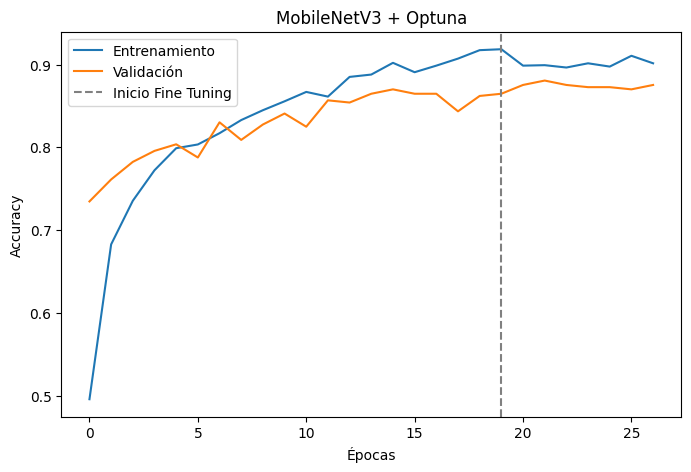

In [22]:
# Gráfico accuracy

plt.figure(figsize=(8,5))

plt.plot(acc_optuna, label="Entrenamiento")
plt.plot(val_acc_optuna, label="Validación")

plt.axvline(
    fine_tune_inicio - 1,
    linestyle="--",
    color="gray",
    label="Inicio Fine Tuning"
)

plt.xlabel("Épocas")
plt.ylabel("Accuracy")
plt.title("MobileNetV3 + Optuna")
plt.legend()

plt.show()

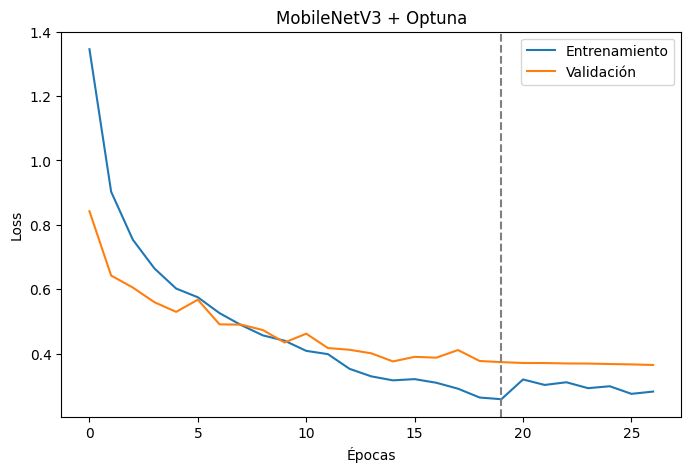

In [23]:
# Gráfico Loss

plt.figure(figsize=(8,5))

plt.plot(loss_optuna, label="Entrenamiento")
plt.plot(val_loss_optuna, label="Validación")

plt.axvline(
    fine_tune_inicio - 1,
    linestyle="--",
    color="gray"
)

plt.xlabel("Épocas")
plt.ylabel("Loss")
plt.title("MobileNetV3 + Optuna")
plt.legend()

plt.show()

12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 93ms/step


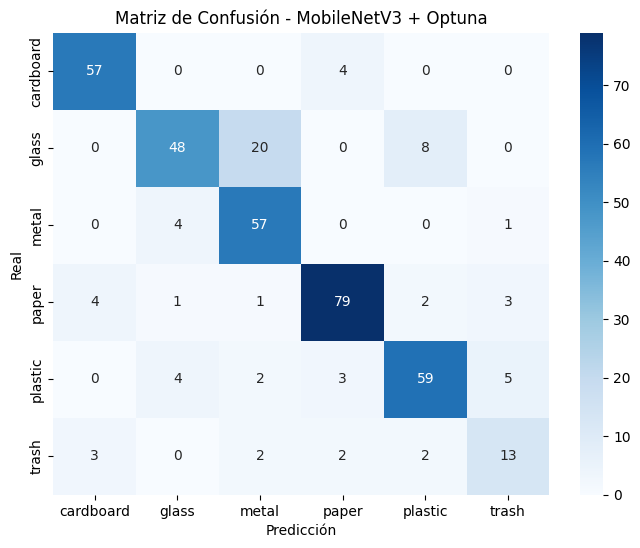

In [25]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Predicciones
y_pred_prob = model_optuna.predict(test_ds, verbose=1)
y_pred = np.argmax(y_pred_prob, axis=1)

# Etiquetas reales
y_true = np.concatenate(
    [np.argmax(y, axis=1) for x, y in test_ds],
    axis=0
)

# Matriz de confusión
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=CLASSES,
    yticklabels=CLASSES
)

plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de Confusión - MobileNetV3 + Optuna")

plt.show()

In [26]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_true,
        y_pred,
        target_names=CLASSES,
        digits=4
    )
)

              precision    recall  f1-score   support

   cardboard     0.8906    0.9344    0.9120        61
       glass     0.8421    0.6316    0.7218        76
       metal     0.6951    0.9194    0.7917        62
       paper     0.8977    0.8778    0.8876        90
     plastic     0.8310    0.8082    0.8194        73
       trash     0.5909    0.5909    0.5909        22

    accuracy                         0.8151       384
   macro avg     0.7912    0.7937    0.7872       384
weighted avg     0.8226    0.8151    0.8132       384



1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 690ms/step
Clase predicha: glass
Confianza: 94.94%


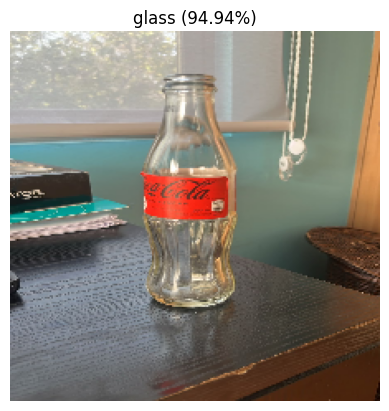

In [27]:
from tensorflow.keras.preprocessing import image

RUTA_IMAGEN = "../imagenes_a_test/test 1.jpeg"

img = image.load_img(
    RUTA_IMAGEN,
    target_size=IMG_SIZE
)

img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)

pred = model_optuna.predict(img_array)

indice = np.argmax(pred[0])

print(f"Clase predicha: {CLASSES[indice]}")
print(f"Confianza: {pred[0][indice]*100:.2f}%")

plt.imshow(img)
plt.axis("off")
plt.title(
    f"{CLASSES[indice]} ({pred[0][indice]*100:.2f}%)"
)
plt.show()

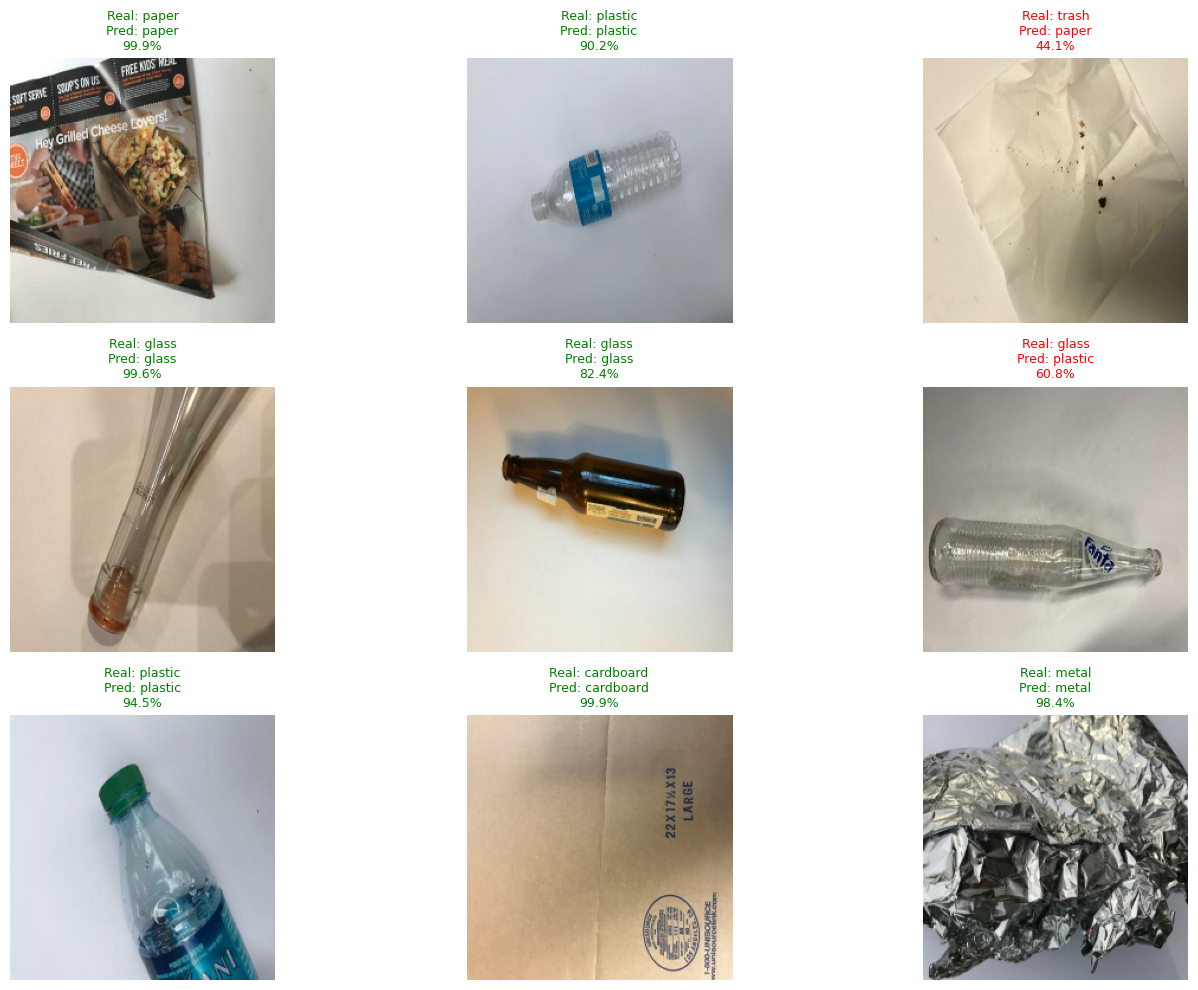

In [28]:
import random

imagenes = []
etiquetas = []

for x, y in test_ds:
    imagenes.extend(x.numpy())
    etiquetas.extend(np.argmax(y.numpy(), axis=1))

plt.figure(figsize=(15,10))

indices = random.sample(range(len(imagenes)), 9)

for i, idx in enumerate(indices):

    img = imagenes[idx]

    pred = model_optuna.predict(
        np.expand_dims(img, axis=0),
        verbose=0
    )

    pred_class = np.argmax(pred)
    conf = np.max(pred)

    plt.subplot(3,3,i+1)

    plt.imshow(img.astype("uint8"))

    color = "green" if pred_class == etiquetas[idx] else "red"

    plt.title(
        f"Real: {CLASSES[etiquetas[idx]]}\n"
        f"Pred: {CLASSES[pred_class]}\n"
        f"{conf*100:.1f}%",
        color=color,
        fontsize=9
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

In [29]:
print("="*60)
print("RESUMEN DEL EXPERIMENTO")
print("="*60)

print(f"Modelo base: MobileNetV3Small")
print(f"Imagen: {IMG_SIZE}")
print(f"Batch Size: {BATCH_SIZE}")

print("\nHiperparámetros encontrados por Optuna")

print(f"Dense Units : {BEST_DENSE_UNITS}")
print(f"Dropout     : {BEST_DROPOUT}")
print(f"LearningRate: {BEST_LR:.6f}")
print(f"Optimizer   : {BEST_OPTIMIZER}")

print("\nResultados")

print(f"Validation Accuracy : {val_acc_final*100:.2f}%")
print(f"Test Accuracy       : {test_acc_final*100:.2f}%")

print("="*60)

RESUMEN DEL EXPERIMENTO
Modelo base: MobileNetV3Small
Imagen: (224, 224)
Batch Size: 32

Hiperparámetros encontrados por Optuna
Dense Units : 256
Dropout     : 0.30000000000000004
LearningRate: 0.000245
Optimizer   : rmsprop

Resultados
Validation Accuracy : 88.06%
Test Accuracy       : 81.51%
